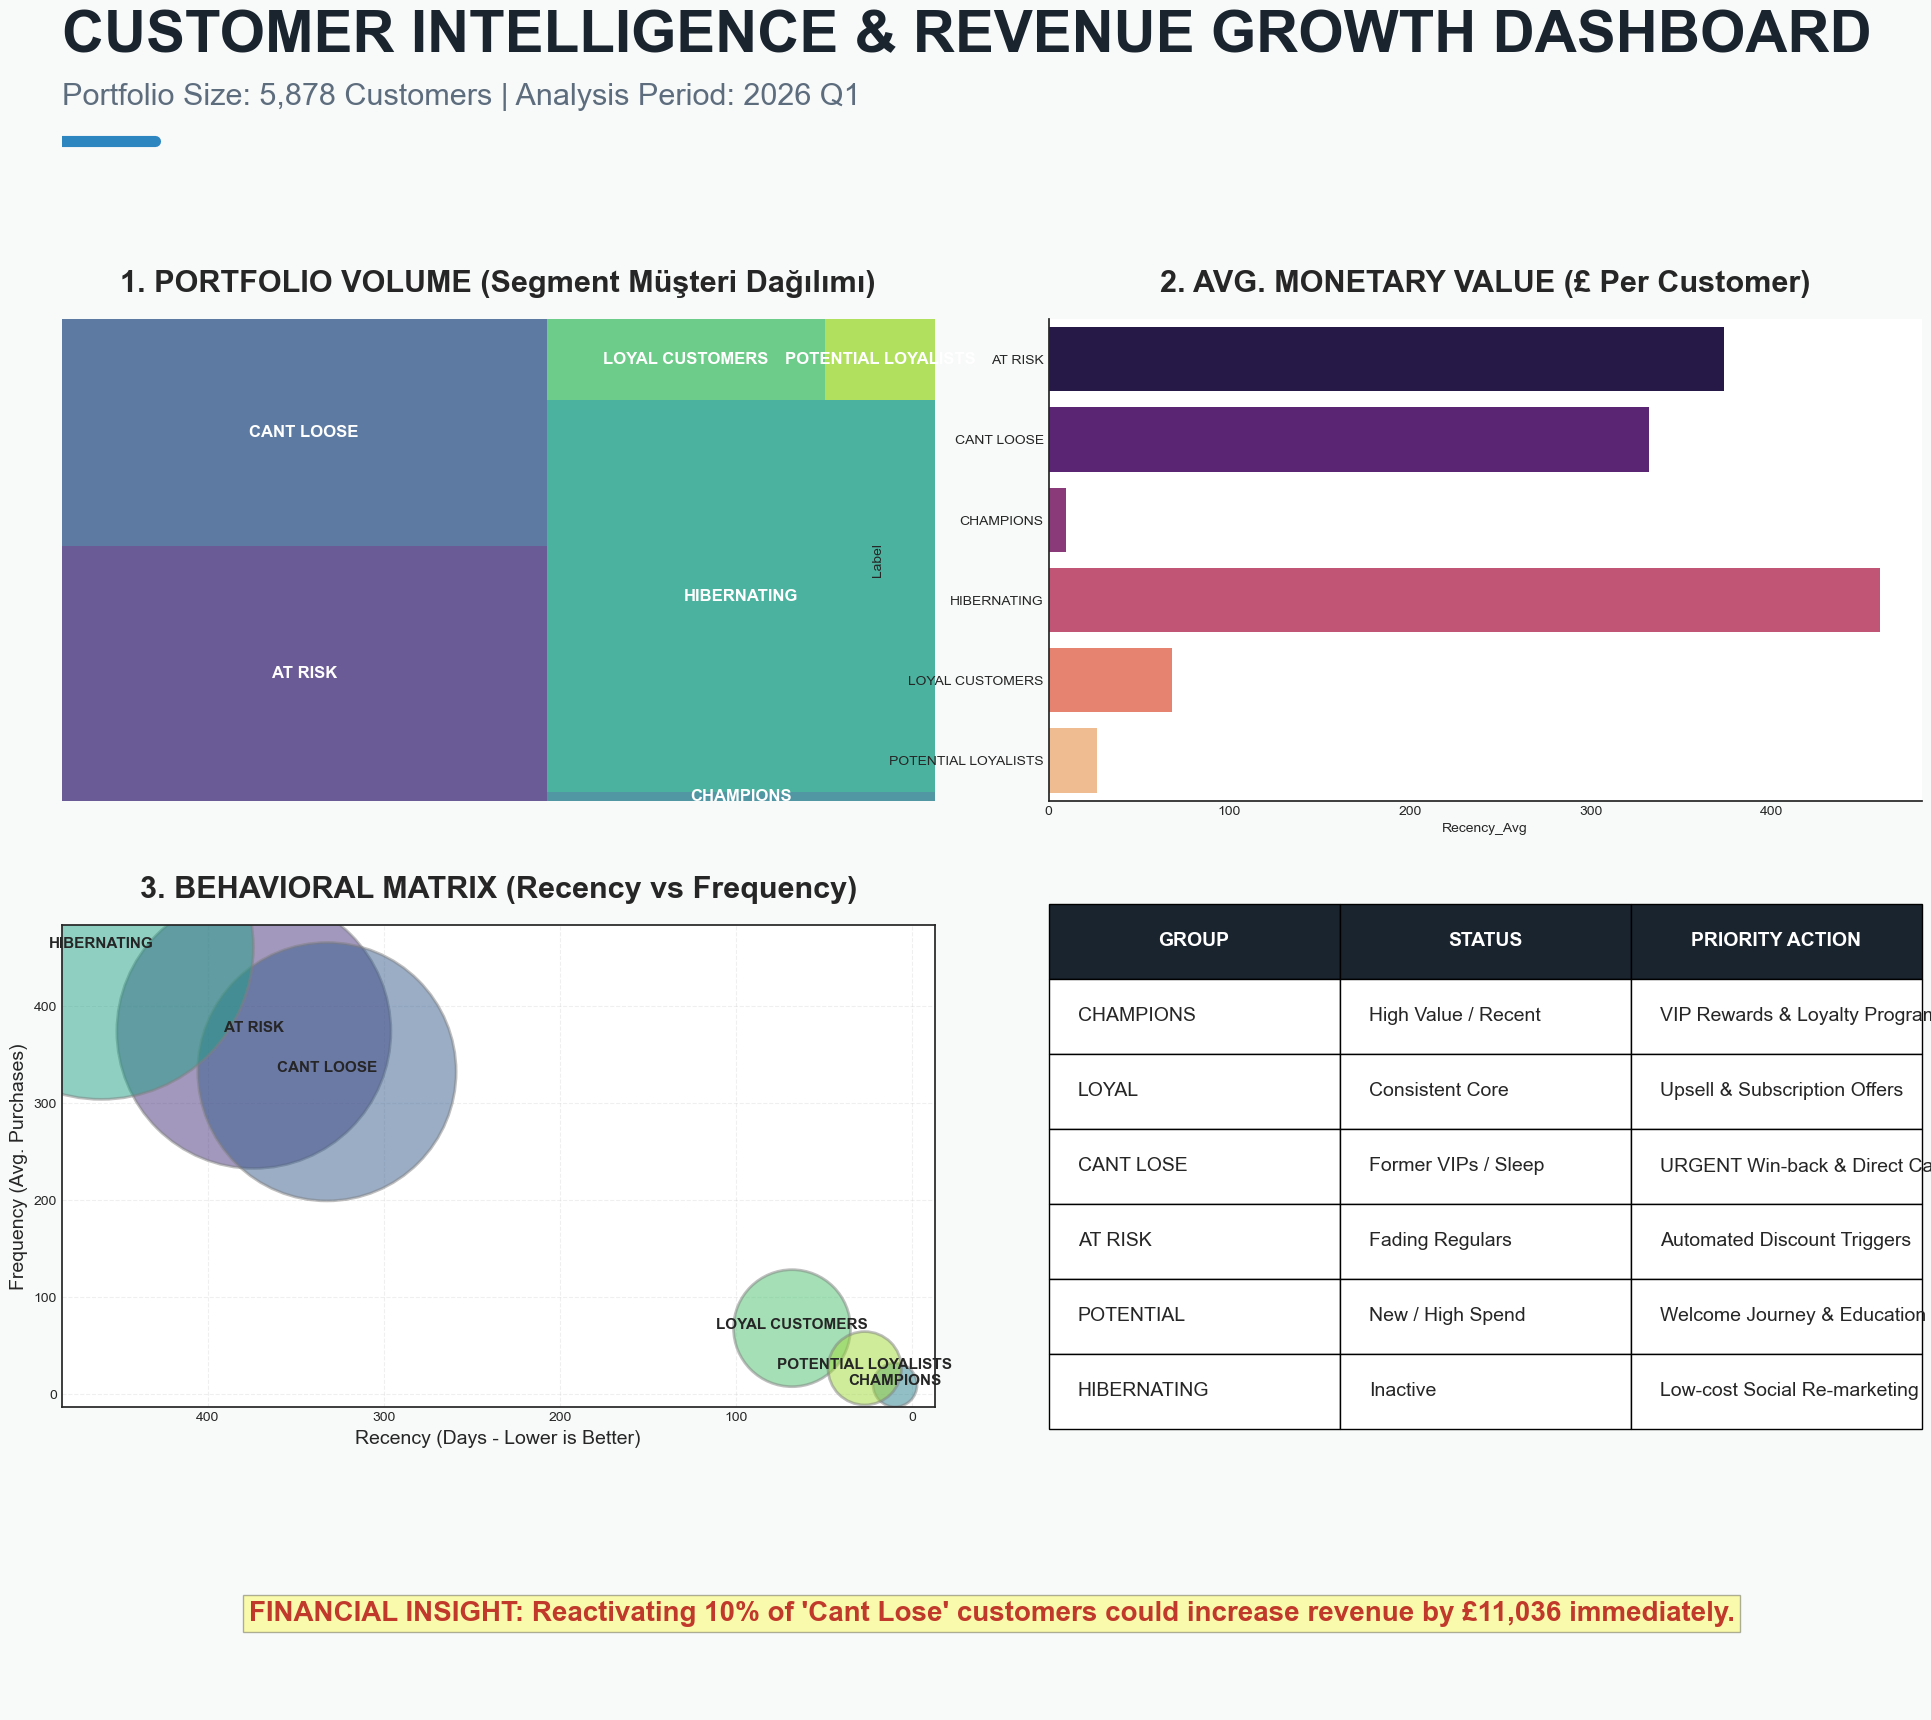

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import squarify # Eğer yüklü değilse: !pip install squarify

# 1. VERİ HAZIRLIĞI VE SÜTUN KONTROLÜ (Savunmacı Programlama)
df_p = rfm_stats.copy()
if isinstance(df_p.columns, pd.MultiIndex):
    df_p.columns = ['_'.join(col).strip() for col in df_p.columns.values]

# Sütunları dinamik ve hatasız bulma fonksiyonu
def find_c(p1, p2):
    match = [c for c in df_p.columns if p1 in c.lower() and p2 in c.lower()]
    return match[0] if match else df_p.select_dtypes(include=[np.number]).columns[0]

rm, fm, mm, mc = find_c('rec','mean'), find_c('freq','mean'), find_c('mon','mean'), find_c('mon','count')

# Hedef segmentler
t_segs = ['champions', 'loyal_customers', 'potential_loyalists', 'at_risk', 'cant_loose', 'hibernating']
df_f = df_p.loc[df_p.index.intersection(t_segs)].copy()
df_f['Label'] = [str(s).replace('_', ' ').upper() for s in df_f.index]

# 2. DASHBOARD TASARIMI
plt.rcParams['font.family'] = 'sans-serif'
fig = plt.figure(figsize=(24, 22), facecolor='#F8F9F9')
gs = plt.GridSpec(6, 4, figure=fig, hspace=0.7, wspace=0.3)

# --- PANEL 1: MODERN HEADER ---
ax0 = fig.add_subplot(gs[0, :])
ax0.axis('off')
ax0.text(0, 0.8, 'CUSTOMER INTELLIGENCE & REVENUE GROWTH DASHBOARD', fontsize=42, weight='bold', color='#1A242F')
ax0.text(0, 0.5, f'Portfolio Size: {len(rfm):,} Customers | Analysis Period: 2026 Q1', fontsize=22, color='#5D6D7E')
ax0.axhline(0.3, color='#2E86C1', linewidth=8, xmin=0, xmax=0.05)

# --- PANEL 2: MARKET SHARE (TREEMAP) ---
ax1 = fig.add_subplot(gs[1:3, 0:2])
c_palette = sns.color_palette('viridis', len(df_f))
squarify.plot(sizes=df_f[mc], label=df_f['Label'], alpha=0.8, color=c_palette, ax=ax1, text_kwargs={'fontsize':12, 'weight':'bold', 'color':'white'})
ax1.set_title("1. PORTFOLIO VOLUME (Segment Müşteri Dağılımı)", fontsize=22, weight='bold', pad=20)
ax1.axis('off')

# --- PANEL 3: FINANCIAL WORTH (BAR CHART) ---
ax2 = fig.add_subplot(gs[1:3, 2:4])
sns.barplot(x=df_f[mm], y=df_f['Label'], hue=df_f['Label'], palette='magma', ax=ax2, legend=False)
ax2.set_title("2. AVG. MONETARY VALUE (£ Per Customer)", fontsize=22, weight='bold', pad=20)
sns.despine(ax=ax2)

# --- PANEL 4: LOYALTY MATRIX (BUBBLE CHART) ---
ax3 = fig.add_subplot(gs[3:5, 0:2])
b_size = (df_f[mm] / df_f[mm].min()) * 1000
ax3.scatter(df_f[rm], df_f[fm], s=b_size, c=c_palette, alpha=0.5, edgecolors='grey', linewidth=2)
for i, txt in enumerate(df_f['Label']):
    ax3.annotate(txt, (df_f[rm].iloc[i], df_f[fm].iloc[i]), fontsize=11, weight='bold', ha='center')
ax3.set_title("3. BEHAVIORAL MATRIX (Recency vs Frequency)", fontsize=22, weight='bold', pad=20)
ax3.set_xlabel("Recency (Days - Lower is Better)", fontsize=14)
ax3.set_ylabel("Frequency (Avg. Purchases)", fontsize=14)
ax3.invert_xaxis()
ax3.grid(True, linestyle='--', alpha=0.3)

# --- PANEL 5: STRATEGIC ACTION TABLE ---
ax4 = fig.add_subplot(gs[3:5, 2:4])
ax4.axis('off')
s_data = [
    ["CHAMPIONS", "High Value / Recent", "VIP Rewards & Loyalty Program"],
    ["LOYAL", "Consistent Core", "Upsell & Subscription Offers"],
    ["CANT LOSE", "Former VIPs / Sleep", "URGENT Win-back & Direct Call"],
    ["AT RISK", "Fading Regulars", "Automated Discount Triggers"],
    ["POTENTIAL", "New / High Spend", "Welcome Journey & Education"],
    ["HIBERNATING", "Inactive", "Low-cost Social Re-marketing"]
]
tbl = ax4.table(cellText=s_data, colLabels=["GROUP", "STATUS", "PRIORITY ACTION"], loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(14)
tbl.scale(1, 4.5)
for (r, c), cell in tbl.get_celld().items():
    if r == 0: cell.set_facecolor('#1A242F'); cell.set_text_props(color='white', weight='bold')

# --- PANEL 6: EXECUTIVE INSIGHT ---
ax5 = fig.add_subplot(gs[5, :])
ax5.axis('off')
msg = f"FINANCIAL INSIGHT: Reactivating 10% of 'Cant Lose' customers could increase revenue by £{ (df_f.loc['cant_loose', mm] * (df_f.loc['cant_loose', mc] * 0.1)):,.0f} immediately."
ax5.text(0.5, 0.5, msg, fontsize=20, weight='bold', ha='center', color='#C0392B', bbox=dict(facecolor='yellow', alpha=0.3))

plt.savefig("Master_Analytics_Dashboard.png", dpi=300, bbox_inches='tight')
plt.show()